# Análisis de Estabilidad Regional de los Determinantes
## Tesis: Benchmarking Explainable Gradient Boosting and Tabular Deep Learning
## for Predicting Satisfaction with Democracy in Latin America (1995–2024)

**Objetivo:** Responder PI3 y OE3 — ¿los determinantes identificados son
estables entre subregiones geográficas?

Requiere haber ejecutado los notebooks 02 y 04 previamente.

### Estructura
| Sección | Contenido |
|---|---|
| 1–2 | Importaciones y configuración |
| 3 | Carga de resultados y del modelo principal |
| 4 | Rendimiento y SHAP por subregión |
| 5 | Comparativa de estrategias de balanceo (E1) |
| 6 | MAE ordinal por país y estrategia |
| 7 | Prueba formal de H4 y H5 (Spearman entre rankings SHAP) |
| 8 | Comparativa de variantes del target (E2) |
| 9 | Resumen y guardado |

> **Alcance de este notebook:** aquí se evalúa la estabilidad *regional* de
> los determinantes, comparando los rankings SHAP calculados para cada
> subregión del conjunto de prueba. La estabilidad *temporal* del rendimiento
> se estima por separado en la sección 19 del NB02, que replica el esquema de
> validación en tres pliegues históricos y reporta la dispersión del kappa
> cuadrático y del MAE ordinal entre períodos.


In [1]:
# imprimir fecha, hora de inicio y modo de ejecución
import datetime
import sys
from pathlib import Path

# Raíz del proyecto en el path (funciona con cwd en notebooks/ o en la raíz)
_root = Path(".").resolve()
if not (_root / "utils").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from utils.config import resumen_modo

print(f"Inicio del programa: {datetime.datetime.now()}")
print()
resumen_modo()


Inicio del programa: 2026-09-06 01:20:04.539177

  MODO CORRIDA REAL — dataset completo y presupuestos completos
Parámetros que dependen del modo:
  CASOS_LIME_DISCORDANTES     : 50
  CASOS_LIME_ERRORES          : 50
  CASOS_LIME_REPRESENTATIVOS  : 100
  EJECUTAR_FOLDS_TEMPORALES   : True
  EPOCAS_TABNET               : 200
  EPOCAS_TABNET_OPTUNA        : 100
  LOAD_SAMPLE                 : False
  MAX_NUMBER_RECORDS          : 12
  MIN_NUMBER_RECORDS          : 8
  N_BOOTSTRAP                 : 1000
  N_BOOTSTRAP_SHAP            : 1000
  N_MUESTRAS_SHAP_OLO         : 500
  N_TRIALS_FOLDS              : 15
  N_TRIALS_OLO                : 20
  N_TRIALS_OPTUNA             : 50
  N_TRIALS_TABNET             : 20
  PACIENCIA_TABNET            : 20
  PACIENCIA_TABNET_OPTUNA     : 15


## 1. Importaciones

In [2]:
import warnings
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from utils.config import (
    setup_plots, PATHS, SPLIT, SUBREGIONES, PAISES_EXCLUIR_EVAL,
    COL_TARGET, COL_PAIS, ETIQUETAS_FEATURES, BLOQUES, PARAMETERS,
)
from utils.io import (
    cargar_pipeline, cargar_split_parquet, cargar_resultados,
    cargar_shap_values, shap_disponible, modelo_xai_seleccionado,
    listar_shap_disponibles,
)
from utils.plots import (
    plot_spearman_estabilidad, plot_shap_por_subregion,
    save_figure,
)
from utils.preprocessing import predecir_conjunto
from sklearn.metrics import (mean_absolute_error, cohen_kappa_score,
                             accuracy_score)

setup_plots()
print("✓ Importaciones completadas.")


✓ Importaciones completadas.


## 2. Configuración

In [3]:
# =============================================================================
# Parámetros del notebook
#
# El modelo principal y su estrategia se leen de la selección que escribe el
# NB03. Debe ser la misma que usó el NB04 al guardar los valores SHAP, porque
# la estrategia forma parte del nombre del archivo.
# =============================================================================
MODELO_PRINCIPAL, ESTRATEGIA_PPAL = modelo_xai_seleccionado(
    fallback_modelo="CatBoost", fallback_estrategia="pesos_clase")
MODELOS = PARAMETERS["MODELOS"]

print(f"Modelo principal  : {MODELO_PRINCIPAL}")
print(f"Estrategia ppal   : {ESTRATEGIA_PPAL}")
print(f"Olas de prueba    : {SPLIT['test']}")
print(f"Países excluidos  : {PAISES_EXCLUIR_EVAL}")
print(f"Subregiones       : {list(SUBREGIONES.keys())}")


Modelo principal (selección del NB03): CatBoost [smotenc]
Modelo principal  : CatBoost
Estrategia ppal   : smotenc
Olas de prueba    : [2023, 2024]
Países excluidos  : ['Venezuela', 'Nicaragua']
Subregiones       : ['Cono Sur', 'Región Andina', 'Brasil', 'Centroamérica', 'México y Caribe']


## 3. Carga de resultados y del modelo principal

Se cargan las métricas del NB02, el conjunto de prueba y el artefacto del
modelo principal. La correlación de Spearman entre rankings SHAP —que es la
prueba formal de H5— se calcula en la sección 7.

- **r ≥ 0.7**: los mismos factores explican la satisfacción en todas las regiones
- **0.5 ≤ r < 0.7**: estabilidad moderada
- **r < 0.5**: cambio estructural entre subregiones


In [4]:
# =============================================================================
# Cargar resultados y datos del split de prueba
# =============================================================================
df_res = cargar_resultados(split="test")
df_te  = cargar_split_parquet("test")

# Cargar artefacto del modelo principal
art   = cargar_pipeline(MODELO_PRINCIPAL, ESTRATEGIA_PPAL)
feats = art["features"]

print(f"Test set cargado: {len(df_te):,} registros")
print(f"Países: {sorted(df_te[COL_PAIS].unique()) if COL_PAIS in df_te.columns else 'N/A'}")


Test set cargado: 35,084 registros
Países: ['Argentina', 'Bolivia', 'Brasil', 'Chile', 'Colombia', 'Costa Rica', 'Ecuador', 'El Salvador', 'Guatemala', 'Honduras', 'México', 'Panamá', 'Paraguay', 'Perú', 'República Dominicana', 'Uruguay']


## 4. Rendimiento y SHAP por subregión

Rendimiento del modelo principal en cada subregión (MAE, Kappa, accuracy) e
importancia SHAP media por subregión.


In [5]:
# =============================================================================
# Análisis de rendimiento por subregión — modelo principal
# =============================================================================
if COL_PAIS not in df_te.columns:
    print("⚠ Columna pais_nombre no disponible en el test parquet")
else:
    y_pred_all, _ = predecir_conjunto(art, df_te)
    y_true_all = df_te[COL_TARGET].values.astype(int)

    filas_sr = []
    for sr_name, paises_sr in SUBREGIONES.items():
        mask = df_te[COL_PAIS].isin(paises_sr)
        if mask.sum() == 0:
            continue
        y_t = y_true_all[mask.values]
        y_p = y_pred_all[mask.values]
        mae  = mean_absolute_error(y_t, y_p)
        kappa = cohen_kappa_score(y_t, y_p, weights="quadratic") if len(set(y_t))>1 else float("nan")
        acc  = accuracy_score(y_t, y_p)
        mejor_pais = None; peor_pais = None
        min_mae = 999; max_mae = -1
        for p in paises_sr:
            mp = df_te[COL_PAIS] == p
            if mp.sum() < 5:
                continue
            mae_p = mean_absolute_error(y_true_all[mp.values], y_pred_all[mp.values])
            if mae_p < min_mae: min_mae = mae_p; mejor_pais = p
            if mae_p > max_mae: max_mae = mae_p; peor_pais  = p
        filas_sr.append({"subregion":sr_name, "n_registros":mask.sum(),
                          "mae_ordinal":round(mae,4), "kappa_cuadratico":round(kappa,4),
                          "accuracy":round(acc,4), "mejor_pais":mejor_pais,
                          "peor_pais":peor_pais})
        print(f"  {sr_name:<22}: MAE={mae:.4f}  \u03ba={kappa:.4f}  Acc={acc:.4f}")

    df_sr = pd.DataFrame(filas_sr)
    df_sr.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "mae_subregiones.csv", index=False)
    print()
    print("\u2713 Guardado: results/tables/mae_subregiones.csv")
    print("  \u2192 Tabla 5.9 de la tesis: MAE por subregión")


  Cono Sur              : MAE=0.5788  κ=0.5042  Acc=0.4973
  Región Andina         : MAE=0.4908  κ=0.4519  Acc=0.5697
  Brasil                : MAE=0.5457  κ=0.5364  Acc=0.5148
  Centroamérica         : MAE=0.6292  κ=0.5480  Acc=0.4858
  México y Caribe       : MAE=0.5945  κ=0.5217  Acc=0.5065

✓ Guardado: results/tables/mae_subregiones.csv
  → Tabla 5.9 de la tesis: MAE por subregión


Top 5 variables SHAP por subregión:
  Cono Sur              : ['Apoyo a la democracia', 'Componente igualitario', 'Confianza Gobierno', 'Situación económica país', 'Aprobación gobierno']
  Región Andina         : ['Apoyo a la democracia', 'Confianza Gobierno', 'Situación económica país', 'Aprobación gobierno', 'País para todos / poderosos']
  Brasil                : ['Apoyo a la democracia', 'Situación económica país', 'Confianza Gobierno', 'Aprobación gobierno', 'País para todos / poderosos']
  Centroamérica         : ['Apoyo a la democracia', 'Confianza Gobierno', 'Situación económica país', 'Aprobación gobierno', 'Componente igualitario']
  México y Caribe       : ['Apoyo a la democracia', 'Situación económica país', 'Confianza Gobierno', 'Aprobación gobierno', 'Distribución ingreso justa']


  ✓ Figura guardada: 05_shap_por_subregion.png


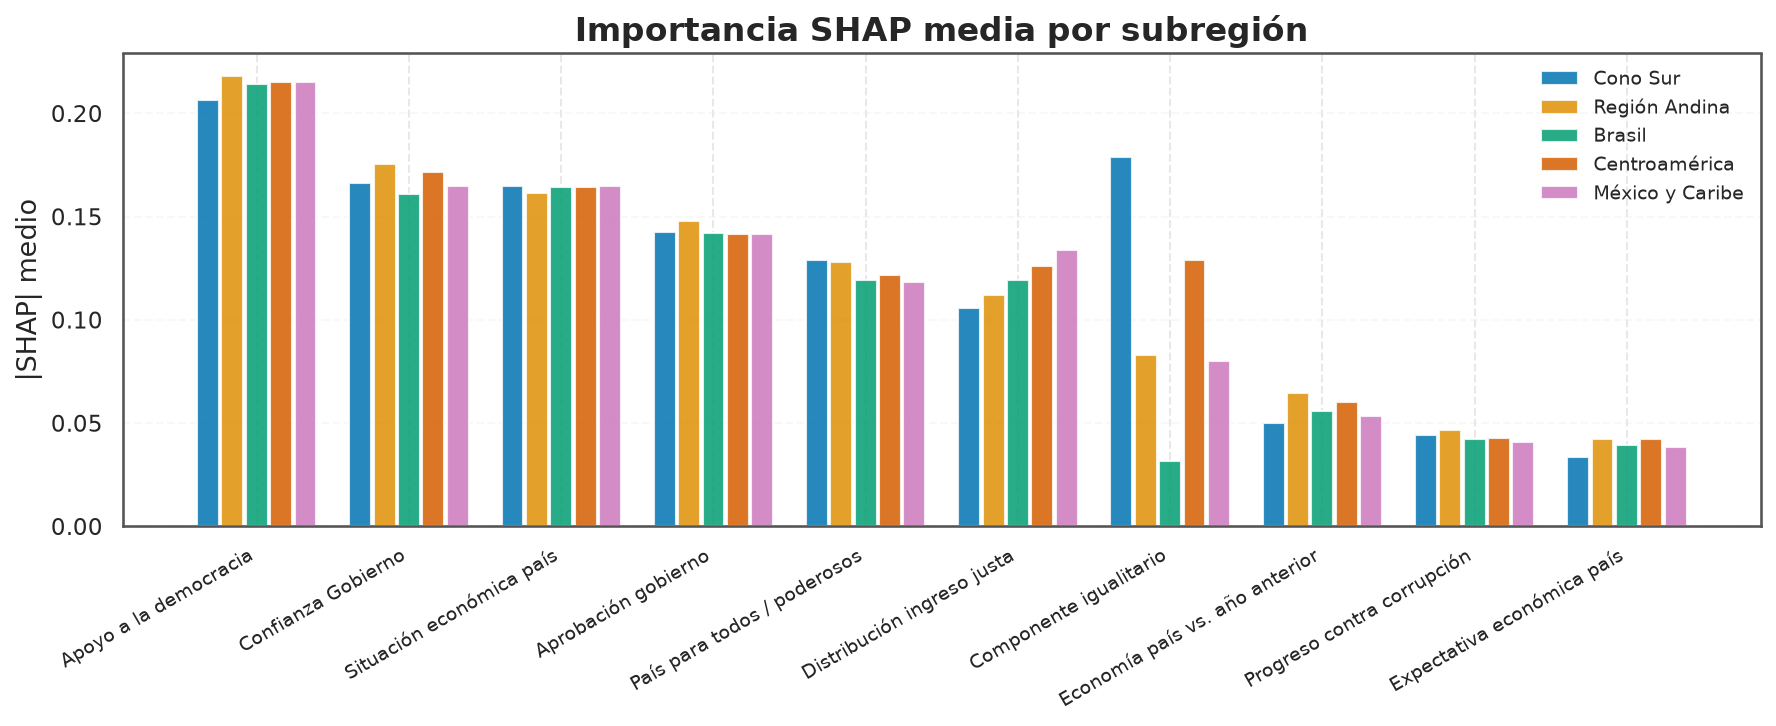

In [6]:
# =============================================================================
# SHAP medio por subregión — top 5 variables por región
# =============================================================================
if not shap_disponible(MODELO_PRINCIPAL, estrategia=ESTRATEGIA_PPAL):
    print(f"\u26a0 Sin valores SHAP para {MODELO_PRINCIPAL} [{ESTRATEGIA_PPAL}] — ejecutar NB04.")
    print(listar_shap_disponibles().to_string(index=False))
elif COL_PAIS not in df_te.columns:
    print("\u26a0 pais_nombre no disponible en test.parquet \u2014 agregar fix en NB02")
else:
    df_shap_all = cargar_shap_values(MODELO_PRINCIPAL, estrategia=ESTRATEGIA_PPAL)
    df_te_r = df_te.reset_index(drop=True)

    dict_sr = {}
    for sr_name, paises_sr in SUBREGIONES.items():
        mask = df_te_r[COL_PAIS].isin(paises_sr)
        if mask.sum() < 20:
            continue
        dict_sr[sr_name] = df_shap_all[mask].abs().mean()

    if dict_sr:
        df_shap_sr = pd.DataFrame(dict_sr)
        print("Top 5 variables SHAP por subregión:")
        for sr_name in df_shap_sr.columns:
            top5 = df_shap_sr[sr_name].sort_values(ascending=False).head(5).index.tolist()
            etiq = [ETIQUETAS_FEATURES.get(v, v) for v in top5]
            print(f"  {sr_name:<22}: {etiq}")
        plot_shap_por_subregion(df_shap_sr, nombre_archivo="05_shap_por_subregion")
    else:
        print("\u26a0 Sin subregiones con datos suficientes (mín. 20 registros)")


## 5. Comparativa de estrategias de balanceo (E1)

Rendimiento de cada estrategia de balanceo sobre el conjunto de prueba.
El desglose de precision/recall/F1 por categoría del modelo principal —la
evidencia directa para H2— se produce en la sección 7 del NB03.


In [7]:
# =============================================================================
# Comparativa E1: Rendimiento en clases minoritarias por estrategia
# ¿SMOTE-NC mejora el F1 de la clase 0 (Para nada satisfecho)?
# =============================================================================
df_test_res = cargar_resultados(split="test")
df_ord = df_test_res[df_test_res["variante_target"]=="ordinal_4clases"].copy()

if not df_ord.empty:
    print("F1 de clase 0 (Para nada satisfecho) por estrategia:")
    print("(Calculado sobre las predicciones del conjunto de prueba)")
    print()
    for est in ["sin_balanceo","pesos_clase","smotenc"]:
        sub = df_ord[df_ord["estrategia_balanceo"]==est]
        if sub.empty:
            print(f"  {est}: sin resultados")
            continue
        mejor = sub.loc[sub["kappa_cuadratico"].idxmax()]
        print(f"  {est:<15}: Kappa={mejor['kappa_cuadratico']:.4f}  "
              f"F1_macro={mejor['f1_macro']:.4f}  Acc={mejor['accuracy']:.4f}")

    df_ord.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "comparativa_estrategias_balanceo.csv", index=False)
    print()
    print("✓ Guardado: results/tables/comparativa_estrategias_balanceo.csv")
    print("  → Tabla 5.X de la tesis: Comparativa E1")
else:
    print("⚠ Sin resultados de E1 — ejecutar NB02")


F1 de clase 0 (Para nada satisfecho) por estrategia:
(Calculado sobre las predicciones del conjunto de prueba)

  sin_balanceo   : Kappa=0.5178  F1_macro=0.4653  Acc=0.5191
  pesos_clase    : Kappa=0.5374  F1_macro=0.4607  Acc=0.4747
  smotenc        : Kappa=0.5386  F1_macro=0.4782  Acc=0.5158

✓ Guardado: results/tables/comparativa_estrategias_balanceo.csv
  → Tabla 5.X de la tesis: Comparativa E1


## 6. MAE ordinal por país y estrategia


In [8]:
# =============================================================================
# Análisis de rendimiento por país para las 3 estrategias de balanceo
# Métrica: MAE ordinal (robusta ante clases minoritarias)
# =============================================================================
df_te_mae = cargar_split_parquet("test")
filas_mae = []

for estrat in ["sin_balanceo", "pesos_clase", "smotenc"]:
    if COL_PAIS not in df_te_mae.columns:
        print("\u26a0 pais_nombre no disponible \u2014 agregar fix en NB02")
        break

    y_te = df_te_mae[COL_TARGET].astype(int).values

    for modelo in MODELOS:
        try:
            art_m  = cargar_pipeline(modelo, estrat)
            y_pred, _ = predecir_conjunto(art_m, df_te_mae)

            for pais in df_te_mae[COL_PAIS].unique():
                if pais in PAISES_EXCLUIR_EVAL:
                    continue
                mask = df_te_mae[COL_PAIS] == pais
                if mask.sum() < 10:
                    continue
                mae = mean_absolute_error(y_te[mask.values], y_pred[mask.values])
                sr  = next((s for s, ps in SUBREGIONES.items() if pais in ps), "Sin clasificar")
                filas_mae.append({
                    "modelo": modelo, "estrategia_balanceo": estrat,
                    "pais": pais, "subregion": sr,
                    "mae_ordinal": mae, "n": int(mask.sum()),
                })
        except FileNotFoundError:
            pass
        except Exception as e:
            print(f"  \u26a0 {modelo} {estrat}: {e}")

df_mae_completo = pd.DataFrame(filas_mae)
if not df_mae_completo.empty:
    print("MAE Ordinal promedio por modelo y estrategia:")
    pivot_mae = (df_mae_completo.groupby(["modelo", "estrategia_balanceo"])["mae_ordinal"]
                 .mean().unstack().round(4))
    print(pivot_mae.to_string())
    df_mae_completo.to_csv(
        PATHS["FOLDER_RESULTS_TABLES"] / "mae_por_pais_todos.csv", index=False)
    print("\n\u2713 Tabla MAE completa guardada")
else:
    print("\u26a0 Sin datos MAE \u2014 verificar pipelines y pais_nombre en test.parquet")


MAE Ordinal promedio por modelo y estrategia:
estrategia_balanceo  pesos_clase  sin_balanceo  smotenc
modelo                                                 
CatBoost                  0.6470        0.5476   0.5732
LightGBM                  0.6524        0.5489   0.5659
OLO                       0.7481        0.5656   0.7381
TabNet                    0.6630        0.5591   0.6761
XGBoost                   0.6478        0.5502   0.5730

✓ Tabla MAE completa guardada


  ✓ Figura guardada: 05_mae_subregion_estrategia_CatBoost.png


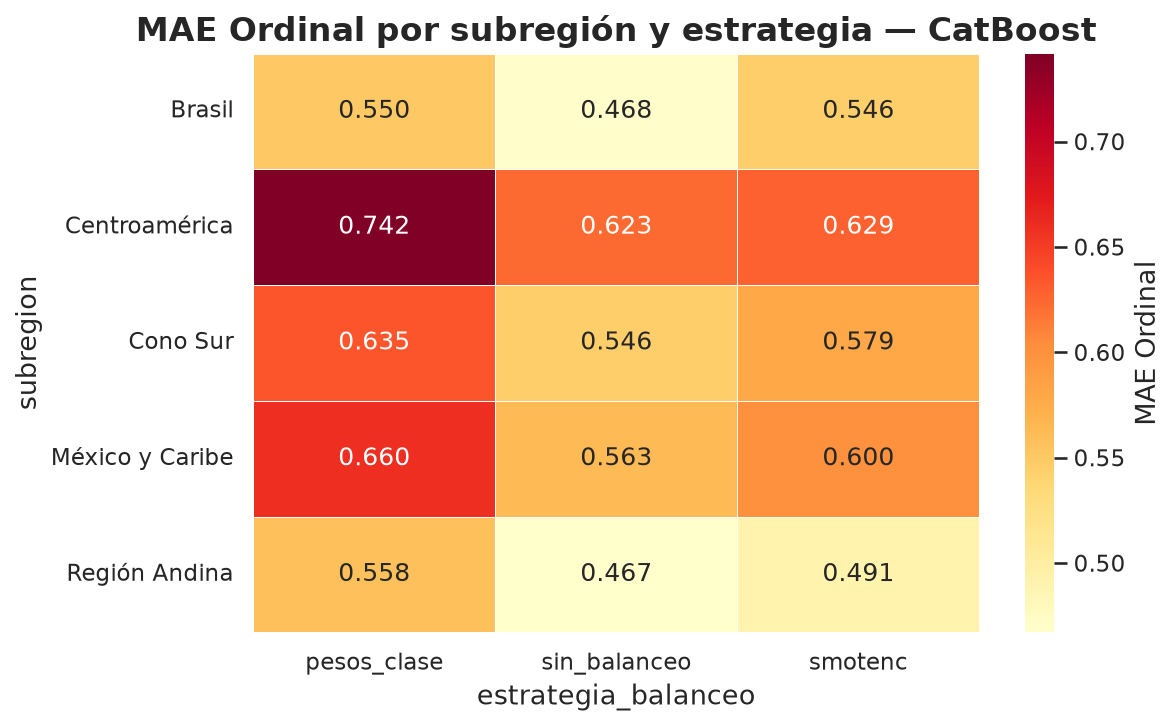

In [9]:
# Heatmap: MAE por subregión × estrategia para el modelo principal
if not df_mae_completo.empty:
    df_sr_sp = (df_mae_completo[df_mae_completo["modelo"] == MODELO_PRINCIPAL]
                .groupby(["subregion", "estrategia_balanceo"])["mae_ordinal"].mean()
                .unstack())

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(df_sr_sp, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.3, ax=ax,
                cbar_kws={"label": "MAE Ordinal"})
    ax.set_title(f"MAE Ordinal por subregión y estrategia \u2014 {MODELO_PRINCIPAL}",
                 fontweight="bold")
    save_figure(f"05_mae_subregion_estrategia_{MODELO_PRINCIPAL}")
    plt.show()


## 7. Prueba formal de H4 y H5

**H4:** la importancia de las variables varía entre subregiones geográficas,
con corrupción y confianza institucional mostrando mayor variación regional.

**H5:** la correlación Spearman entre los rankings de importancia SHAP de
distintas subregiones es alta (r ≥ 0.7), indicando que los determinantes
identificados son robustos y generalizables en toda América Latina.


PRUEBA DE H4
Variación de importancia SHAP por bloque entre subregiones:

  Confianza institucional                   : rango=0.0025  mayor en 'Región Andina'  menor en 'Brasil'
  Evaluación económica                      : rango=0.0083  mayor en 'Centroamérica'  menor en 'Cono Sur'
  Percepción política                       : rango=0.0047  mayor en 'Región Andina'  menor en 'México y Caribe'
  Corrupción y seguridad                    : rango=0.0019  mayor en 'Región Andina'  menor en 'México y Caribe'
  Características sociodemográficas         : rango=0.0000  mayor en 'Cono Sur'  menor en 'México y Caribe'
  Contexto democrático                      : rango=0.0373  mayor en 'Cono Sur'  menor en 'Brasil'

PRUEBA DE H5
Correlación Spearman entre rankings SHAP de subregiones:

                 Cono Sur  Región Andina  Brasil  Centroamérica  México y Caribe
Cono Sur           1.0000         0.9905  0.9669         0.9955           0.9894
Región Andina      0.9905         1.0000  0.9905 

  ✓ Figura guardada: 05_spearman_subregiones.png


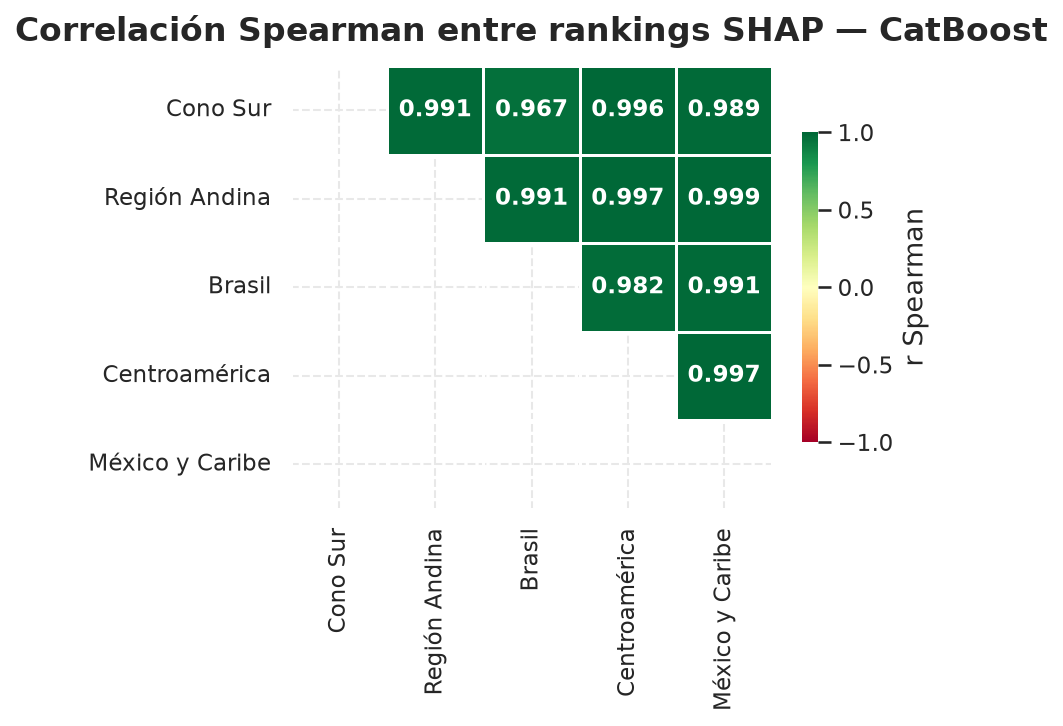

✓ Guardado: results/tables/spearman_subregiones.csv


In [10]:
# =============================================================================
# Prueba de H4 y H5: estabilidad de determinantes entre subregiones
# Con diseño de split único la estabilidad temporal no aplica; se evalúa
# la estabilidad regional comparando rankings SHAP entre subregiones.
# =============================================================================
if not shap_disponible(MODELO_PRINCIPAL, estrategia=ESTRATEGIA_PPAL):
    print(f"\u26a0 Sin valores SHAP para {MODELO_PRINCIPAL} [{ESTRATEGIA_PPAL}] — ejecutar NB04.")
    print(listar_shap_disponibles().to_string(index=False))
elif COL_PAIS not in df_te.columns:
    print("\u26a0 pais_nombre no disponible \u2014 agregar fix en NB02")
else:
    df_shap_all = cargar_shap_values(MODELO_PRINCIPAL, estrategia=ESTRATEGIA_PPAL)
    df_te_r = df_te.reset_index(drop=True)

    dict_sr = {}
    for sr_name, paises_sr in SUBREGIONES.items():
        mask = df_te_r[COL_PAIS].isin(paises_sr)
        if mask.sum() < 20:
            continue
        dict_sr[sr_name] = df_shap_all[mask].abs().mean()

    if len(dict_sr) < 2:
        print("\u26a0 Insuficientes subregiones con datos SHAP (mín. 2 con \u226520 registros)")
    else:
        df_shap_sr = pd.DataFrame(dict_sr)

        print("=" * 60)
        print("PRUEBA DE H4")
        print("=" * 60)
        print("Variación de importancia SHAP por bloque entre subregiones:")
        print()
        for bloque, vars_b in BLOQUES.items():
            vars_pres = [v for v in vars_b if v in df_shap_sr.index]
            if not vars_pres:
                continue
            imp_bloque = df_shap_sr.loc[vars_pres].mean()
            rango   = imp_bloque.max() - imp_bloque.min()
            sr_max  = imp_bloque.idxmax()
            sr_min  = imp_bloque.idxmin()
            print(f"  {bloque:<42}: rango={rango:.4f}  "
                  f"mayor en '{sr_max}'  menor en '{sr_min}'")

        print()
        print("=" * 60)
        print("PRUEBA DE H5")
        print("=" * 60)
        print("Correlación Spearman entre rankings SHAP de subregiones:")
        print()

        srs = df_shap_sr.columns.tolist()
        n_sr = len(srs)
        corr_matrix = pd.DataFrame(index=srs, columns=srs, dtype=float)
        for sri in srs:
            for srj in srs:
                r, _ = stats.spearmanr(df_shap_sr[sri], df_shap_sr[srj])
                corr_matrix.loc[sri, srj] = round(r, 4)

        print(corr_matrix.to_string())
        print()

        vals_tri = [corr_matrix.loc[srs[i], srs[j]]
                    for i in range(n_sr) for j in range(i)]
        r_min  = min(vals_tri) if vals_tri else float("nan")
        r_mean = sum(vals_tri) / len(vals_tri) if vals_tri else float("nan")

        print(f"  Correlación mínima : {r_min:.4f}")
        print(f"  Correlación media  : {r_mean:.4f}")
        print()

        if r_min >= 0.7:
            print("  \u2713 H5 CONFIRMADA: r_min \u2265 0.7 \u2014 los determinantes son")
            print("    robustos entre subregiones de América Latina.")
        elif r_min >= 0.5:
            print("  ~ H5 PARCIALMENTE CONFIRMADA: 0.5 \u2264 r_min < 0.7 \u2014")
            print("    los determinantes muestran estabilidad moderada.")
        else:
            print("  \u2717 H5 NO CONFIRMADA: r_min < 0.5 \u2014 existe cambio")
            print("    estructural entre subregiones.")

        plot_spearman_estabilidad(
            corr_matrix.astype(float),
            titulo=f"Correlación Spearman entre rankings SHAP \u2014 {MODELO_PRINCIPAL}",
            nombre_archivo="05_spearman_subregiones"
        )

        corr_matrix.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "spearman_subregiones.csv")
        print("\u2713 Guardado: results/tables/spearman_subregiones.csv")


## 8. Comparativa de variantes del target (E2)


In [11]:
# =============================================================================
# Análisis de variantes del target (E2)
# Pregunta: ¿varía el rendimiento según la formulación del target?
# =============================================================================
try:
    df_res_all = cargar_resultados(split=None)
    df_e2_sub = df_res_all[
        (df_res_all["split"] == "test") &
        (df_res_all["estrategia_balanceo"] == ESTRATEGIA_PPAL)
    ].copy() if "variante_target" in df_res_all.columns else pd.DataFrame()

    if not df_e2_sub.empty and "variante_target" in df_e2_sub.columns:
        print("Kappa cuadrático por modelo y variante del target:")
        print(f"(estrategia: {ESTRATEGIA_PPAL})")
        pivot = df_e2_sub.pivot_table(
            index="modelo", columns="variante_target",
            values="kappa_cuadratico", aggfunc="mean"
        )
        cols_ord = [c for c in ["ordinal_4clases", "binario"]
                    if c in pivot.columns]
        print(pivot[cols_ord].to_string(float_format="{:.4f}".format))
        print()
        print("F1 Macro (binario comparable con Rosa et al. 2023: 0.84-0.85):")
        pivot_f1 = df_e2_sub.pivot_table(
            index="modelo", columns="variante_target",
            values="f1_macro", aggfunc="mean"
        )
        print(pivot_f1[cols_ord].to_string(float_format="{:.4f}".format))
        df_e2_sub.to_csv(
            PATHS["FOLDER_RESULTS_TABLES"] / "comparativa_e2_subregion.csv",
            index=False
        )
        print("\n✓ Guardado: results/tables/comparativa_e2_subregion.csv")
    else:
        print("⚠ Sin datos E2 — ejecutar NB02 bloque E2 primero")
except Exception as e:
    print(f"⚠ Error: {e}")


Kappa cuadrático por modelo y variante del target:
(estrategia: smotenc)
variante_target  ordinal_4clases
modelo                          
CatBoost                  0.5386
LightGBM                  0.5051
OLO                       0.5308
TabNet                    0.5208
XGBoost                   0.5150

F1 Macro (binario comparable con Rosa et al. 2023: 0.84-0.85):
variante_target  ordinal_4clases
modelo                          
CatBoost                  0.4782
LightGBM                  0.4635
OLO                       0.3977
TabNet                    0.4468
XGBoost                   0.4753

✓ Guardado: results/tables/comparativa_e2_subregion.csv


## 9. Resumen y guardado


In [12]:
print("=" * 60)
print("RESUMEN \u2014 Análisis de estabilidad temporal y regional")
print("=" * 60)
print(f"  Modelo analizado : {MODELO_PRINCIPAL}")
print(f"  Estrategia       : {ESTRATEGIA_PPAL}")
print(f"  Split de prueba  : test (2023\u20132024)")
print()
print("Archivos generados:")
for f in sorted(PATHS["FOLDER_RESULTS_FIGURES"].glob("05_*.png")):
    print(f"  {f.name}")
for f in sorted(PATHS["FOLDER_RESULTS_TABLES"].glob("*spearman*")):
    print(f"  {f.name}")
for f in sorted(PATHS["FOLDER_RESULTS_TABLES"].glob("*mae*")):
    print(f"  {f.name}")


RESUMEN — Análisis de estabilidad temporal y regional
  Modelo analizado : CatBoost
  Estrategia       : smotenc
  Split de prueba  : test (2023–2024)

Archivos generados:
  05_mae_subregion_estrategia_CatBoost.png
  05_shap_por_subregion.png
  05_spearman_subregiones.png
  spearman_subregiones.csv
  mae_por_pais_test.csv
  mae_por_pais_todos.csv
  mae_subregiones.csv


In [13]:
# imprimir fecha y hora de fin del programa
print(f"Fin del programa: {datetime.datetime.now()}")

Fin del programa: 2026-09-06 01:20:09.520455
